<a href="https://colab.research.google.com/github/quinterogilalejandro-wq/Entregable-15-Algoritmos-NO-supervisados/blob/main/Entregable_15_Algoritmos_NO_supervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving DATASET_INmuebles.xlsx to DATASET_INmuebles (4).xlsx
Dataset cargado:
  Inmueble  area_m2  habitaciones  estrato  precio_arriendo
0       I1       69             2        2          1413951
1       I2       39             1        2          1006165
2       I3      142             5        5          8570904
3       I4       62             3        4          3678698
4       I5       58             1        3           875729

Columnas disponibles: ['Inmueble', 'area_m2', 'habitaciones', 'estrato', 'precio_arriendo']
Total registros: 1000

Dataset con clusters asignados:
    Inmueble  area_m2  habitaciones  estrato  precio_arriendo  cluster
0         I1       69             2        2          1413951        0
1         I2       39             1        2          1006165        0
2         I3      142             5        5          8570904        1
3         I4       62             3        4          3678698        2
4         I5       58             1        3           87572

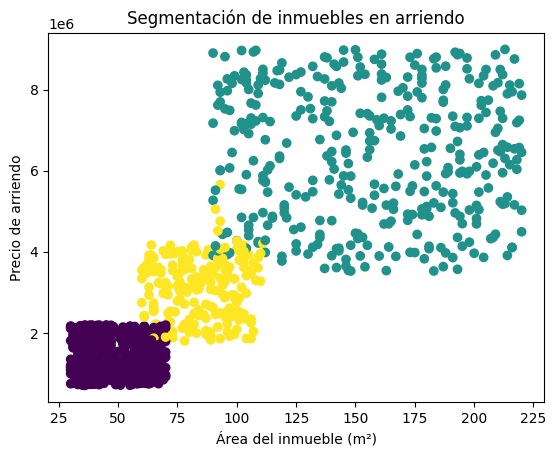


Resumen promedio por cluster:
            area_m2  habitaciones   estrato  precio_arriendo
cluster                                                     
0         49.658711      1.525060  2.501193     1.469202e+06
1        156.129032      4.029570  5.534946     6.353200e+06
2         85.358852      2.516746  4.057416     3.130625e+06


In [17]:
# ============================================================
# LABORATORIO: Segmentación de inmuebles en arriendo
# Algoritmo no supervisado: K-Means
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. Cargar dataset desde archivo local
# ============================================================

uploaded = files.upload()  # Selecciona DATASET_INmuebles.xlsx

filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))

# Renombrar columnas al momento de cargar
df = df.rename(columns={
    "Área m²": "area_m2",
    "Habitaciones": "habitaciones",
    "Estrato": "estrato",
    "Precio arriendo": "precio_arriendo"
})

print("Dataset cargado:")
print(df.head())
print(f"\nColumnas disponibles: {df.columns.tolist()}")
print(f"Total registros: {len(df)}")

# ============================================================
# 2. Seleccionar variables para clustering
# ============================================================

X = df[[
    "area_m2",
    "habitaciones",
    "estrato",
    "precio_arriendo"
]]

# ============================================================
# 3. Escalamiento de datos
# ============================================================

# K-Means usa distancias.
# Por eso es importante escalar los datos,
# ya que el precio tiene valores mucho más grandes que las otras variables.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 4. Aplicar K-Means
# ============================================================

# Vamos a crear 3 grupos de inmuebles:
# Cluster 0, Cluster 1 y Cluster 2

modelo = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

modelo.fit(X_scaled)

# Agregar el cluster al dataframe original
df["cluster"] = modelo.labels_

print("\nDataset con clusters asignados:")
print(df)

# ============================================================
# 5. Ver centroides
# ============================================================

centroides = modelo.cluster_centers_

print("\nCentroides escalados:")
print(centroides)

# Para interpretar mejor los centroides,
# los devolvemos a la escala original.

centroides_originales = scaler.inverse_transform(centroides)

df_centroides = pd.DataFrame(
    centroides_originales,
    columns=[
        "area_m2",
        "habitaciones",
        "estrato",
        "precio_arriendo"
    ]
)

print("\nCentroides en escala original:")
print(df_centroides)

# ============================================================
# 6. Visualización básica
# ============================================================

plt.scatter(
    df["area_m2"],
    df["precio_arriendo"],
    c=df["cluster"]
)

plt.xlabel("Área del inmueble (m²)")
plt.ylabel("Precio de arriendo")
plt.title("Segmentación de inmuebles en arriendo")
plt.show()

# ============================================================
# 7. Resumen por cluster
# ============================================================

resumen = df.groupby("cluster")[
    [
        "area_m2",
        "habitaciones",
        "estrato",
        "precio_arriendo"
    ]
].mean()

print("\nResumen promedio por cluster:")
print(resumen)

Saving DATASET_INmuebles.xlsx to DATASET_INmuebles (5).xlsx
Dataset cargado:
  Inmueble  area_m2  habitaciones  estrato  precio_arriendo
0       I1       69             2        2          1413951
1       I2       39             1        2          1006165
2       I3      142             5        5          8570904
3       I4       62             3        4          3678698
4       I5       58             1        3           875729

Columnas disponibles: ['Inmueble', 'area_m2', 'habitaciones', 'estrato', 'precio_arriendo']
Total registros: 1000

Dataset con clusters asignados:
    Inmueble  area_m2  habitaciones  estrato  precio_arriendo  cluster
0         I1       69             2        2          1413951        0
1         I2       39             1        2          1006165        0
2         I3      142             5        5          8570904        1
3         I4       62             3        4          3678698        0
4         I5       58             1        3           87572

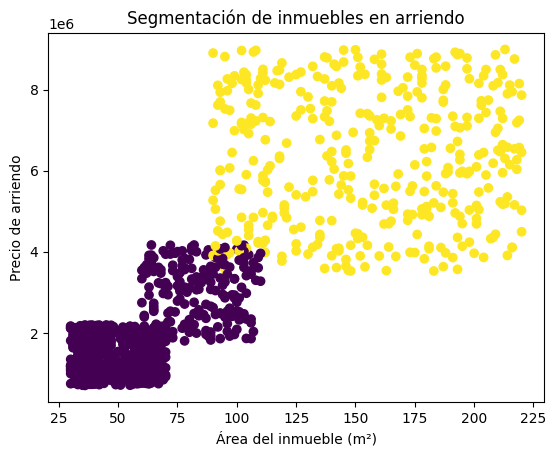


Resumen promedio por cluster:
            area_m2  habitaciones   estrato  precio_arriendo
cluster                                                     
0         60.980583      1.831715  2.983819     1.984490e+06
1        154.557592      4.010471  5.526178     6.300712e+06


In [18]:
# ============================================================
# LABORATORIO: Segmentación de inmuebles en arriendo
# Algoritmo no supervisado: K-Means
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. Cargar dataset desde archivo local
# ============================================================

uploaded = files.upload()  # Selecciona DATASET_INmuebles.xlsx

filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))

# Renombrar columnas al momento de cargar
df = df.rename(columns={
    "Área m²": "area_m2",
    "Habitaciones": "habitaciones",
    "Estrato": "estrato",
    "Precio arriendo": "precio_arriendo"
})

print("Dataset cargado:")
print(df.head())
print(f"\nColumnas disponibles: {df.columns.tolist()}")
print(f"Total registros: {len(df)}")

# ============================================================
# 2. Seleccionar variables para clustering
# ============================================================

X = df[[
    "area_m2",
    "habitaciones",
    "estrato",
    "precio_arriendo"
]]

# ============================================================
# 3. Escalamiento de datos
# ============================================================

# K-Means usa distancias.
# Por eso es importante escalar los datos,
# ya que el precio tiene valores mucho más grandes que las otras variables.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 4. Aplicar K-Means
# ============================================================

# Vamos a crear 3 grupos de inmuebles:
# Cluster 0, Cluster 1 y Cluster 2

modelo = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

modelo.fit(X_scaled)

# Agregar el cluster al dataframe original
df["cluster"] = modelo.labels_

print("\nDataset con clusters asignados:")
print(df)

# ============================================================
# 5. Ver centroides
# ============================================================

centroides = modelo.cluster_centers_

print("\nCentroides escalados:")
print(centroides)

# Para interpretar mejor los centroides,
# los devolvemos a la escala original.

centroides_originales = scaler.inverse_transform(centroides)

df_centroides = pd.DataFrame(
    centroides_originales,
    columns=[
        "area_m2",
        "habitaciones",
        "estrato",
        "precio_arriendo"
    ]
)

print("\nCentroides en escala original:")
print(df_centroides)

# ============================================================
# 6. Visualización básica
# ============================================================

plt.scatter(
    df["area_m2"],
    df["precio_arriendo"],
    c=df["cluster"]
)

plt.xlabel("Área del inmueble (m²)")
plt.ylabel("Precio de arriendo")
plt.title("Segmentación de inmuebles en arriendo")
plt.show()

# ============================================================
# 7. Resumen por cluster
# ============================================================

resumen = df.groupby("cluster")[
    [
        "area_m2",
        "habitaciones",
        "estrato",
        "precio_arriendo"
    ]
].mean()

print("\nResumen promedio por cluster:")
print(resumen)

Saving DATASET_INmuebles.xlsx to DATASET_INmuebles (6).xlsx
Dataset cargado:
  Inmueble  area_m2  habitaciones  estrato  precio_arriendo
0       I1       69             2        2          1413951
1       I2       39             1        2          1006165
2       I3      142             5        5          8570904
3       I4       62             3        4          3678698
4       I5       58             1        3           875729

Columnas disponibles: ['Inmueble', 'area_m2', 'habitaciones', 'estrato', 'precio_arriendo']
Total registros: 1000

Dataset con clusters asignados:
    Inmueble  area_m2  habitaciones  estrato  precio_arriendo  cluster
0         I1       69             2        2          1413951        0
1         I2       39             1        2          1006165        0
2         I3      142             5        5          8570904        2
3         I4       62             3        4          3678698        3
4         I5       58             1        3           87572

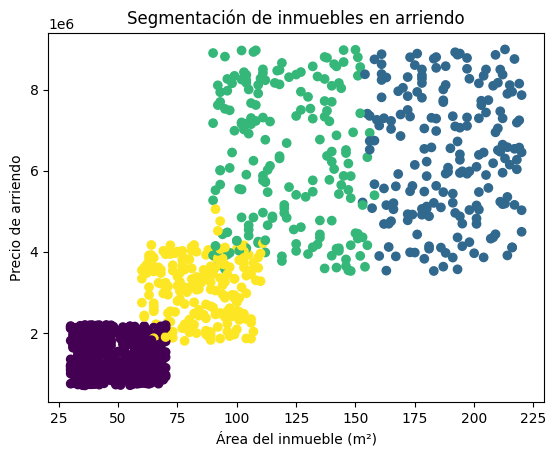


Resumen promedio por cluster:
            area_m2  habitaciones   estrato  precio_arriendo
cluster                                                     
0         49.658711      1.525060  2.501193     1.469202e+06
1        188.921053      3.952632  5.510526     6.392509e+06
2        121.058511      4.090426  5.553191     6.243451e+06
3         85.054187      2.487685  4.019704     3.100224e+06


In [19]:
# ============================================================
# LABORATORIO: Segmentación de inmuebles en arriendo
# Algoritmo no supervisado: K-Means
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. Cargar dataset desde archivo local
# ============================================================

uploaded = files.upload()  # Selecciona DATASET_INmuebles.xlsx

filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))

# Renombrar columnas al momento de cargar
df = df.rename(columns={
    "Área m²": "area_m2",
    "Habitaciones": "habitaciones",
    "Estrato": "estrato",
    "Precio arriendo": "precio_arriendo"
})

print("Dataset cargado:")
print(df.head())
print(f"\nColumnas disponibles: {df.columns.tolist()}")
print(f"Total registros: {len(df)}")

# ============================================================
# 2. Seleccionar variables para clustering
# ============================================================

X = df[[
    "area_m2",
    "habitaciones",
    "estrato",
    "precio_arriendo"
]]

# ============================================================
# 3. Escalamiento de datos
# ============================================================

# K-Means usa distancias.
# Por eso es importante escalar los datos,
# ya que el precio tiene valores mucho más grandes que las otras variables.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 4. Aplicar K-Means
# ============================================================

# Vamos a crear 3 grupos de inmuebles:
# Cluster 0, Cluster 1 y Cluster 2

modelo = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

modelo.fit(X_scaled)

# Agregar el cluster al dataframe original
df["cluster"] = modelo.labels_

print("\nDataset con clusters asignados:")
print(df)

# ============================================================
# 5. Ver centroides
# ============================================================

centroides = modelo.cluster_centers_

print("\nCentroides escalados:")
print(centroides)

# Para interpretar mejor los centroides,
# los devolvemos a la escala original.

centroides_originales = scaler.inverse_transform(centroides)

df_centroides = pd.DataFrame(
    centroides_originales,
    columns=[
        "area_m2",
        "habitaciones",
        "estrato",
        "precio_arriendo"
    ]
)

print("\nCentroides en escala original:")
print(df_centroides)

# ============================================================
# 6. Visualización básica
# ============================================================

plt.scatter(
    df["area_m2"],
    df["precio_arriendo"],
    c=df["cluster"]
)

plt.xlabel("Área del inmueble (m²)")
plt.ylabel("Precio de arriendo")
plt.title("Segmentación de inmuebles en arriendo")
plt.show()

# ============================================================
# 7. Resumen por cluster
# ============================================================

resumen = df.groupby("cluster")[
    [
        "area_m2",
        "habitaciones",
        "estrato",
        "precio_arriendo"
    ]
].mean()

print("\nResumen promedio por cluster:")
print(resumen)